# **The 6-step Data Quality Method**
## https://github.com/royruddle/6-step-data-quality-method

This is the notebook that is used in the YouTube video about **Step 5** of the method (https://www.youtube.com/watch?v=BIrYUAYY7K4), and shows how to use the vizdataquality package to investigate data quality.

The 6 steps are:
1. Is anything obviously wrong?
2. Watch out for special values
3. Is any data missing?
4. Check each variable
5. Check combinations of variables
6. Profile the cleaned data

## **Step 5: Check combinations of variables  (do they violate any of your assumptions or business rules?)**

This step uses off-street parking fines data ('Quarter 4 201819.csv'; https://datamillnorth.org/dataset/v8ggw/off-street-parking-fines), (c) Leeds City Council, 2019. The data is licensed under the terms of the Open Government Licence (https://www.nationalarchives.gov.uk/doc/open-government-licence/version/2/).

Checks performed:
- Very old PCNs (ISSUED 2009): Number of unique values (all 8 variables)
- Recent PCNs (issued 2017 onward):
    - Violate functional dependencies: [Last Pay Date, ISSUED]
    - Violate assumptions: [CONTRAVENTION, FINE] and [PCN, Total Paid, Last Pay Date]
- PCNs issued in current quarter (Jan - Mar 2019):
    - Violate functional dependencies: [FINE, Total Paid, Balance]

## Includes: vizdataquality and other libraries

In [1]:
import os
import pandas as pd

from vizdataquality import calculate as vdqc, plot as vdqp

## Read the data file

In [2]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Quarter 4 201819.csv')

# Read the dataset, but only treat empty cells as missing values
df = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False,
                 parse_dates=['ISSUED', 'Last Pay Date'], dayfirst=True, low_memory=False)

# Perform cleaning that was done in Steps 1 and 4
#   - Drop the unnnamed, empty columns
#   - Strip leading/trailing spaces in LOCATION and CONTRAVENTION values
df = df.drop(columns=df.columns[-1])
df['LOCATION'] = df['LOCATION'].apply(lambda x: x.strip())
df['CONTRAVENTION'] = df['CONTRAVENTION'].apply(lambda x: x.strip())

## How many PCNs were ISSUED each year?

RECAP: Dataset is for January - March 2019, but Steps 1  and 4 showed some very old (2009) PCNs

In [3]:
print('Number of PCNs ISSUED each year:')
print(df.drop_duplicates(['PCN', 'ISSUED'])['ISSUED'].apply(lambda x: x.year).value_counts()
    .sort_index())

Number of PCNs ISSUED each year:
ISSUED
2009      93
2017       7
2018     930
2019    2911
Name: count, dtype: int64


## Very old PCNs (ISSUED 2009)

In [4]:
df2009 = df[df['ISSUED'] <= pd.to_datetime('2009-12-31', yearfirst=True)]

### Calculate the number of unique values in each column

In [5]:
column_stats2009 = vdqc.calc(df2009, {'Unique values': True})
print(column_stats2009['Number of unique values'])

_column
PCN              93
ISSUED           56
LOCATION         16
CONTRAVENTION     5
FINE              2
Last Pay Date     1
Total Paid        1
Balance           1
Name: Number of unique values, dtype: int64


### Print unique values

In [6]:
print('PCNs issued in 2009:')
print('  Number of rows =', len(df2009))
print('  Number of unique PCNs =', df2009['PCN'].nunique())

for col in df2009.columns[-4:]:
    print(' ', col, 'values =', df2009[col].unique().tolist())

PCNs issued in 2009:
  Number of rows = 93
  Number of unique PCNs = 93
  FINE values = [50, 70]
  Last Pay Date values = [Timestamp('2019-03-28 00:00:00')]
  Total Paid values = [0.0]
  Balance values = [0.0]


## Recent PCNs (issued 2017 onward)

In [7]:
df_recent = df[df['ISSUED'] >= pd.to_datetime('2017-01-01', yearfirst=True)]

### Violate functional dependencies

#### Check Last Pay Date is never earlier than ISSUED

In [8]:
num_errors = len(df_recent[df_recent['Last Pay Date'] < df_recent['ISSUED']])
print('Number of errors =', num_errors)

Number of errors = 0


### Violate assumptions

#### Check each CONTRAVENTION has one value of FINE

In [9]:
df_contravention_fine = df_recent[['CONTRAVENTION', 'FINE']].drop_duplicates()

if len(df_contravention_fine) == df_recent['CONTRAVENTION'].nunique():
    print('Each CONTRAVENTION has one value of FINE', '\n')
else:
    print('*** ERROR *** One or more CONTRAVENTIONS has multiple FINE values', '\n')

Each CONTRAVENTION has one value of FINE 



#### For each PCN, check Total Paid always increases over time

In [10]:
num_errors = 0
num_increase = 0

# Group the rows by PCN
for name, group in df_recent.groupby(by='PCN'):
    last_value = None
    index = group.columns.tolist().index('Total Paid')
    
    # Loop over the rows for this PCN
    for row in group.sort_values(by=['Last Pay Date', 'Total Paid']).itertuples(index=False):

        if last_value is not None:
            # PCN occurs in 2+ rows
            if row[index] <= last_value:
                num_errors += 1
            else:
                num_increase += 1

        last_value = row[index]

print('Number of rows that adhere to assumption =', num_increase)
print('Number of errors (Total Paid did not increase) =', num_errors)

Number of rows that adhere to assumption = 0
Number of errors (Total Paid did not increase) = 3167


#### Cross-check the finding using drop_duplicates()

In [11]:
duplicate_columns = df_recent.columns.tolist()
duplicate_columns.remove('Last Pay Date')
df_dropped = df_recent.drop_duplicates(duplicate_columns).copy()
print('Columns used for duplicate check:', duplicate_columns)
print('df_recent: Number of rows =', len(df_recent), 'number of PCNs = ', df_recent['PCN'].nunique())
print('df_dropped: Number of rows =', len(df_dropped), 'number of PCNs = ',
      df_dropped['PCN'].nunique())

Columns used for duplicate check: ['PCN', 'ISSUED', 'LOCATION', 'CONTRAVENTION', 'FINE', 'Total Paid', 'Balance']
df_recent: Number of rows = 7015 number of PCNs =  3848
df_dropped: Number of rows = 3848 number of PCNs =  3848


## PCNs issued in current quarter (Jan - Mar 2019)

RECAP: Step 1 "Example Values" showed values of [FINE, Total Paid, Balance] that do not add up

### Violate functional dependencies

#### Add 'count' column (number of rows containing each PCN)

In [12]:
df_2019 = df[df['ISSUED'] >= pd.to_datetime('2019-01-01', yearfirst=True)]
df_numrows = pd.merge(pd.DataFrame(df_2019['PCN'].value_counts().reset_index()), df_2019,
                      how='left', on='PCN').sort_values(['PCN', 'Last Pay Date'])
print(df_numrows['count'].value_counts().sort_index())

count
1     830
2    2998
3    1719
4      36
Name: count, dtype: int64


#### Print examples for 1-row PCN, 2-row PCN, etc.

In [13]:
columns = ['PCN', 'ISSUED', 'FINE', 'Total Paid', 'Balance', 'Last Pay Date']
for num_PCN_rows in range(1, 5):
    df_nrows = df_numrows[df_numrows['count'] == num_PCN_rows]
    
    for name, group in df_nrows[columns].groupby('PCN'):
        print(group)
        break

             PCN     ISSUED  FINE  Total Paid  Balance Last Pay Date
4758  LS01752750 2019-01-03    50        25.0     50.0    2019-01-03
             PCN     ISSUED  FINE  Total Paid  Balance Last Pay Date
1805  LS01752728 2019-01-03    50        50.0      0.0    2019-01-03
1806  LS01752728 2019-01-03    50        50.0      0.0    2019-01-30
            PCN     ISSUED  FINE  Total Paid  Balance Last Pay Date
325  LS0175320A 2019-01-14    50        25.0      0.0    2019-01-14
324  LS0175320A 2019-01-14    50        25.0      0.0    2019-01-15
326  LS0175320A 2019-01-14    50        25.0      0.0    2019-01-16
          PCN     ISSUED  FINE  Total Paid  Balance Last Pay Date
6  LS03549452 2019-01-14    50        25.0      0.0    2019-01-14
4  LS03549452 2019-01-14    50        25.0      0.0    2019-01-15
7  LS03549452 2019-01-14    50        25.0      0.0    2019-01-16
5  LS03549452 2019-01-14    50        25.0      0.0    2019-01-26


#### For 1st PCN row, check Balance = FINE - Total Paid

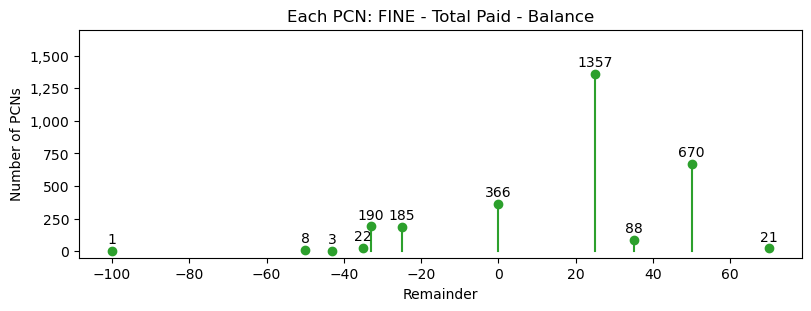

In [14]:
# Only use the one row for each PCN ('Last Pay Date' is the only column that changes)
duplicate_columns = df_2019.columns.tolist()
duplicate_columns.remove('Last Pay Date')
df_dropped = df_2019.drop_duplicates(duplicate_columns).copy()
df_dropped['Remainder'] = df_dropped['FINE'] - df_dropped['Total Paid'] - df_dropped['Balance']

fig_kw = {'size_inches': (8, 3), 'constrained_layout': True}
ax_kw = {'title': 'Each PCN: FINE - Total Paid - Balance', 'xlabel': 'Remainder',
         'ylabel': 'Number of PCNs', 'ylim': (-50, 1700)}
vdqp.lollipop(df_dropped['Remainder'].value_counts(), datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)